# Visualizing Finite Element Mesh

## Visualization of Truss

Consider the example truss shown below:

![Example truss](graphics/SystematicTrussAnalysis-2.png){fig-align="center" width=20em #fig-truss}

With the data provided by the typical data set:

```default
P:
0,   0     # Node 1
500, 0     # Node 2
300, 300   # Node 3
600, 300   # Node 4


elements: 
1, 2   # Element 1 connects nodes 1 and 2
1, 3   # Element 2 connects nodes 1 and 3
2, 3   # Element 3 connects nodes 2 and 3
2, 4   # Element 4 connects nodes 2 and 4
3, 4   # Element 5 connects nodes 3 and 4

Displacement vector u (in mm)
Format: [u1x, u1y, u2x, u2y, u3x, u3y, u4x, u4y]

u: [0, 0, -0.1984127, 0, 0.24666587, 0.09005164, 0.44507857, -0.91164825]

It is implied that the displacements in node 1 are zero in both x and y direction 
and that the displacements in node 2 are zero in y direction.

# Element forces N (in N)
# Positive = tension, Negative = compression
N: [16800,  20000, -22360, 0]

# Reaction forces (in N)
# Format: [R1x, R1y, R2x, R2y, R3x, R3y, R4x, R4y]
R: [3200,  10000,  16800,  0, 0, -10000, -20000,  0]

# External forces (in N)
# Format: [Fx1, Fy1]
F = [0, -10000.0] # Acting at node 4
```

We want to do the following:

- Visualize the truss from  @fig-truss, including lines, nodes, and both nodal numbers and element numbers in the middle of the lines
- Visualize the point load (F) using a vector arrow in the correct location and direction.
- Visualize the reaction forces (R) using vector arrows in the correct location and direction.
- Visualize the element forces (N) using color coding, where red is tension and blue is compression.
- Visualize the deformed truss using the nodal displacements (u).
- Visualize the nodal resulting displacements (u) on the deformed truss by color coding the truss bars using linearly interpolated colors based on the nodal displacements.

## Implementing FEM mesh algorithms in Python: The Array Indexing Problem

These truss analysis results are comming from a Finite Element methodology, where the geometry is given by a computational mesh. This mesh consists of data structures that are not directly compatible with python. The nodal coordinates are given by the vertices of the mesh, and the element connectivity is given by the edges of the mesh. The connectivity matrix `elements` is a matrix of size `N x 2`, where `N` is the number of elements. The coordinate (or nodes) matrix `P` is a matrix of size `M x 2`, where `M` is the number of nodes. This is in 2D, but it can be extended to 3D by an additional column for the z-coordinate. The first column of `elements` is the node number of the first node of the element, and the second column is the node number of the second node of the element. If we want, for example, the nodes of the first element, we need to access the first row of `elements` to grab the nodal numbers `1, 2` for the first element. These indices are then used to access the nodal coordinates from the `P` matrix. Notice here, in this description, we use natural language to say "first" element, "second" column, etc. This is because in a FEM setting, the mesh is typically 1-indexed. This goes beyond this simple example, in commercial FEM software, the mesh data is given 1-indexed and has typically an addination column for numbering the nodes and elements since we can have a blend of different element types and parts. The problem is if we now want to work with this data in python, we need to use 0-indexing and keep a mental map. 

### Installing MatKit

We begin by loading the necessary libraries, we have a helper library `MatKit` that contains functions for one-indexing mesh data for further processing and visualization.

The library can be found [here](https://github.com/cenmir/MatKit).

Install it using

```bash
uv pip install git+https://github.com/cenmir/MatKit.git
```

Then we can include the helper functions by

In [114]:
# | code-fold: false

import numpy as np
import matplotlib.pyplot as plt
from matkit import Mesh

# For nice plots
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 10

## Visualizing a Truss Mesh


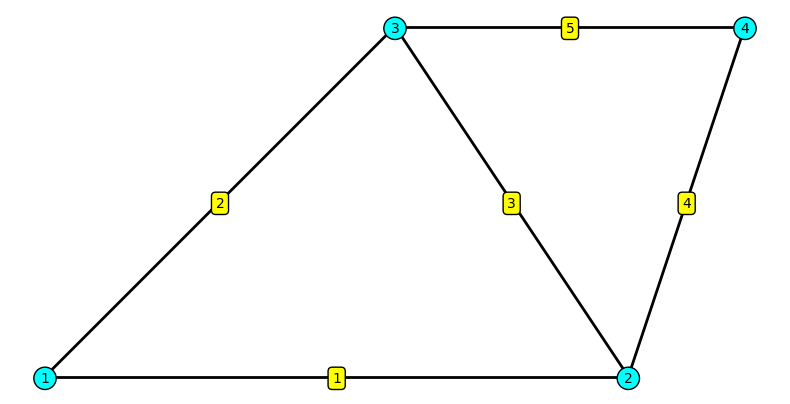

In [115]:
# | code-fold: false

# Node coordinates - same as before
P = np.array([[0, 0],
              [500, 0],
              [300, 300],
              [600, 300]])

# Element connectivity - using natural 1-based node numbers
edges = np.array([[1, 2],
                  [1, 3],
                  [2, 3],
                  [2, 4],
                  [3, 4]])

# Create mesh (auto-detects ROD elements from 2 nodes per element)
mesh = Mesh(P, edges)

# Visualization with MatKit
fig, ax = plt.subplots(figsize=(8, 6))

# Draw elements using natural iteration
for iel in mesh.element_numbers():  # Yields 1, 2, 3, 4, 5
    node_nums, coords = mesh.get_element(iel)  # Natural 1-based access!
    ax.plot(coords[:, 0], coords[:, 1], 'k-', linewidth=2)

# Draw nodes
# ax.plot(P[:, 0], P[:, 1], 'o', color='cyan',
#         markeredgecolor='black', markersize=14)

# Label nodes
for inode in mesh.node_numbers():  # Yields 1, 2, 3, 4
    coord = mesh.get_node(inode)  # Natural 1-based access!
    # ax.text(coord[0] - 20, coord[1], str(inode),
    #         fontsize=12, ha='right')
    ax.text(coord[0], coord[1]-5, str(inode),  # Must add 1 for label!
            bbox=dict(boxstyle='circle', facecolor='cyan'),
            fontsize=10, ha='center')

# Label elements  
for iel in mesh.element_numbers():
    node_nums, coords = mesh.get_element(iel)
    xm = np.mean(coords[:, 0])
    ym = np.mean(coords[:, 1])
    ax.text(xm, ym-5, str(iel),
            bbox=dict(boxstyle='round', facecolor='yellow'),
            fontsize=10, ha='center')

ax.set_aspect('equal')
ax.axis('off')
plt.tight_layout()
plt.show()

### Code Explanation

This code creates a visualization of a finite element truss structure. Here's a breakdown of each section:

#### 1. Data Setup

```python
P = np.array([[0, 0],
              [500, 0],
              [300, 300],
              [600, 300]])
```
- **`P`**: Node coordinates matrix - defines the (x, y) positions of the 4 nodes in millimeters
- Node 1: (0, 0), Node 2: (500, 0), Node 3: (300, 300), Node 4: (600, 300)

```python
edges = np.array([[1, 2],
                  [1, 3],
                  [2, 3],
                  [2, 4],
                  [3, 4]])
```
- **`edges`**: Element connectivity matrix - defines which nodes are connected by each element
- Uses **1-based indexing** (natural numbering) instead of Python's 0-based indexing
- Element 1 connects nodes 1-2, Element 2 connects nodes 1-3, etc.

#### 2. Mesh Creation

```python
mesh = Mesh(P, edges)
```
- Creates a `Mesh` object from the MatKit library
- Automatically detects ROD elements (2 nodes per element)
- Handles the conversion between 1-based and 0-based indexing internally

#### 3. Drawing Elements

```python
for iel in mesh.element_numbers():  # Yields 1, 2, 3, 4, 5
    node_nums, coords = mesh.get_element(iel)
    ax.plot(coords[:, 0], coords[:, 1], 'k-', linewidth=2)
```
- Iterates through elements using **natural 1-based numbering** (1, 2, 3, 4, 5)
- `mesh.get_element(iel)` returns the node numbers and coordinates for element `iel`
- Draws each element as a black line (`'k-'`) with thickness 2

#### 4. Labeling Nodes

```python
for inode in mesh.node_numbers():  # Yields 1, 2, 3, 4
    coord = mesh.get_node(inode)
    ax.text(coord[0], coord[1]-5, str(inode),
            bbox=dict(boxstyle='circle', facecolor='cyan'),
            fontsize=10, ha='center')
```
- Iterates through nodes using **natural 1-based numbering** (1, 2, 3, 4)
- `mesh.get_node(inode)` retrieves the coordinates for node `inode`
- Places text label at position `(x, y-5)` - slightly below the node
- **`bbox`**: Creates a circular background box
  - `boxstyle='circle'`: Makes the box circular
  - `facecolor='cyan'`: Cyan background color
- `ha='center'`: Horizontally centers the text

#### 5. Labeling Elements

```python
for iel in mesh.element_numbers():
    node_nums, coords = mesh.get_element(iel)
    xm = np.mean(coords[:, 0])  # Mean x-coordinate
    ym = np.mean(coords[:, 1])  # Mean y-coordinate
    ax.text(xm, ym-5, str(iel),
            bbox=dict(boxstyle='round', facecolor='yellow'),
            fontsize=10, ha='center')
```
- Calculates the midpoint of each element by averaging the node coordinates
- Places the element number at the midpoint
- **`bbox`**: Creates a rounded rectangular background
  - `boxstyle='round'`: Rounded corners (can be changed to `'circle'` for circular boxes)
  - `facecolor='yellow'`: Yellow background color

#### 6. Final Formatting

```python
ax.set_aspect('equal')  # Equal scaling for x and y axes
ax.axis('off')          # Hide axes
plt.tight_layout()      # Optimize spacing
plt.show()              # Display the figure
```

#### Key Concept: 1-Based vs 0-Based Indexing

The main advantage of using MatKit is that it allows you to work with **natural 1-based indexing** (as used in FEM theory and commercial software) instead of Python's native 0-based indexing. This makes the code more intuitive and matches the mathematical notation used in finite element analysis.


## Visualizing the deformed truss

### Understanding Displacement Data

In finite element analysis, nodal displacements are typically stored in a **1D vector** where the x and y components alternate:

```
u = [u1x, u1y, u2x, u2y, u3x, u3y, u4x, u4y]
```

For our truss example with 4 nodes, the displacement vector from FEM analysis is:

In [116]:
# | code-fold: false
# Import MatKit for 1-based indexing
import matkit as mk
from matkit import display_labeled_latex


In [117]:
# | code-fold: false
# Displacement vector u (in mm)
# Format: [u1x, u1y, u2x, u2y, u3x, u3y, u4x, u4y]
u = np.array([[0, 0, -0.1984127, 0, 0.24666587, 0.09005164, 0.44507857, -0.91164825]])

In [118]:
# | echo: false
display_labeled_latex("\\mathbf{{u}} = ", u,4)

<IPython.core.display.Latex object>

### Reshaping Displacements into a Matrix

For visualization, it's more convenient to organize the displacements as a **matrix** where:

- Each row represents one node
- Column 1 contains x-displacements  
- Column 2 contains y-displacements

```default
U = [[u1x, u1y],    ← Node 1 displacements
     [u2x, u2y],    ← Node 2 displacements
     [u3x, u3y],    ← Node 3 displacements
     [u4x, u4y]]    ← Node 4 displacements
```

We use NumPy's `reshape()` function to reorganize the 1D vector into this 2D matrix:

In [119]:
# | code-fold: false
# Reshape from 1D to 2D matrix (4 nodes × 2 components)
U = u.reshape(-1, 2)  # -1 means "figure out the number of rows automatically"

In [120]:
# | echo: false
display_labeled_latex("\\mathbf{{U}} = ", U, precision=4, show_shape=True)

<IPython.core.display.Latex object>

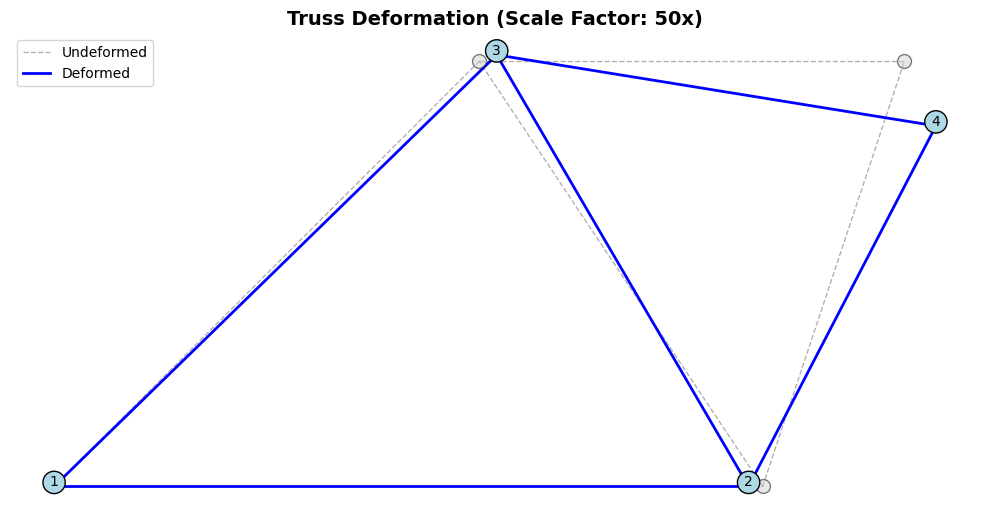

In [121]:
# | code-fold: false
# Scale factor for visualization (to exaggerate deformations)
scale = 50

# Calculate deformed node positions using OneArray for natural 1-based indexing
P_deformed = mk.OneArray(P + scale * U)

# Create figure
fig, ax = plt.subplots(figsize=(10, 7))

# Draw original (undeformed) truss in gray
for iel in mesh.element_numbers():
    node_nums, coords = mesh.get_element(iel)
    ax.plot(coords[:, 0], coords[:, 1], 'k--', linewidth=1, alpha=0.3, 
            label='Undeformed' if iel == 1 else '')

# Draw deformed truss in blue
for iel in mesh.element_numbers():
    node_nums, coords = mesh.get_element(iel)
    coords_deformed = P_deformed[node_nums]  # Natural 1-based indexing!
    ax.plot(coords_deformed[:, 0], coords_deformed[:, 1], 'b-', linewidth=2, 
            label='Deformed' if iel == 1 else '')

# Draw original nodes
ax.plot(P[:, 0], P[:, 1], 'o', color='lightgray', 
        markeredgecolor='black', markersize=10, alpha=0.5)

# Label deformed nodes
for inode in mesh.node_numbers():
    coord_deformed = P_deformed[inode]  # Natural 1-based indexing!
    ax.text(coord_deformed[0], coord_deformed[1], str(inode),
            bbox=dict(boxstyle='circle', facecolor='lightblue'),
            fontsize=10, ha='center')

# Add title and legend
ax.set_title(f'Truss Deformation (Scale Factor: {scale}x)', fontsize=14, fontweight='bold')
ax.legend(loc='upper left')
ax.set_aspect('equal')
ax.axis('off')
plt.tight_layout()
plt.show()